Descripción del proyecto
Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

Delante de ti hay datos que se remontan a 2016. Imaginemos que es diciembre de 2016 y estás planeando una campaña para 2017.

Lo importante es adquirir experiencia de trabajo con datos. Realmente no importa si estás pronosticando las ventas de 2017 en función de los datos de 2016 o las ventas de 2027 en función de los datos de 2026.

El dataset contiene una columna "rating" que almacena la clasificación ESRB de cada juego. El Entertainment Software Rating Board (la Junta de clasificación de software de entretenimiento) evalúa el contenido de un juego y asigna una clasificación de edad como Adolescente o Adulto.

# Paso 1. Abre el archivo de datos y estudia la información general 

In [11]:
#Librerias importadas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

In [12]:
#Importar Dataset
games = pd.read_csv('datasets/games.csv')

# Paso 2. Prepara los datos

##### 2.1 - Reemplaza los nombres de las columnas (ponlos en minúsculas).

In [13]:
#2.1
#Renombrar columnas en minúsculas
games_col= games.columns
games_col= [col.lower() for col in games_col]
games.columns= games_col
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [14]:
#Analizamos la generalidad de la estrucutra del DF y una busqueda superficial de datos duplicados
games.info()
print('Número de juegos duplicados:', games.duplicated().sum())
print('Número de juegos con el mismo nombre:',games['name'].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
Número de juegos duplicados: 0
Número de juegos con el mismo nombre: 5155


##### 2.2 - Convierte los datos en los tipos necesarios.

In [15]:
#2.2
#Cambio de tipos de datos por INT64 para la serie YEAR_OF_RELEASE
games['year_of_release']= games['year_of_release'].astype('Int64')

#Cambio de tipo de datos por FLOAT para la serie CRITIC_SCORE
games['critic_score']= pd.to_numeric(games['critic_score'])

#games.info()

##### 2.3 - Describe las columnas en las que los tipos de datos han sido cambiados y explica por qué.

 2.3
    
    - Se modificará la serie YEAR_OF_RELEASE a INT, esto con la finalidad de dar una mejor presentación a los datos y no alterará la naturaleza de la información.
    - Las otra series a modificar son USER_SCORE y CRITIC_SCORE, ambas cuentan con valores ausentes pero debido a su naturaleza como calificación con número decimal deberán de ser modificadas, sin embargo hasta resolver el problema con el string 'tbd' de la serie USER_SCORE solo se cambiará de momento CRITIC_SCORE

##### 2.4 - Si es necesario, elige la manera de tratar los valores ausentes:

In [16]:
#2.4
#Reemplazo de nulos por 'UNKNOWN' para la serie Genre y 'RP' de Raiting
games['genre']= games['genre'].fillna('Unknown')
games['rating']= games['rating'].fillna('RP')

#print(games[games['year_of_release'].isna()])
#print(games[games['genre']=='Unknown'])
#print(games[(games['rating']=='RP') ])

##### 2.5 - Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.

2.5

    - Para la serie GENRE y RATING los datos nulos serán reemplazados por el string "Unknown" y "RP" (Raiting Pendant) respectivamente, esto para diferenciarlos rapidamente en caso de ser necesario.
    - Al contratrio mantendremos los NaN de las series USER_SCORE, YEAR_OF RELEASE y CRITIC_SCORE, de esta forma no generaremos datos extremos (0) o ruido (en caso de rellenarlo con datos como la media, moda o mediana) y así no alterar las futuras operaciones. De igual forma se mantendran los nulos de las series.

##### 2.6 - ¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.

2.6

    - Al analizar cuales de los juegos fueron modificados por el string "Unknown" dentro de la serie GENRE encontramos que solo se encuentran 2 registros ambos con información incompleta como NAME, CRITIC_SCORE y USER_SCORE pero ambos de la plataforma GENESIS y lanzados en 1993. El primer registro cuenta con información de ventas en todas las regiones menos JP mientras que el segundo solo en JP. Dada esta casualidad podriamos fusionar estos registros en solo 1 pero al no tener certeza de que se trata del mismo juego se mantendran ambos registros.
    - Para el resto de datos ausentes la mayoría de esta perdida de datos se presenta debido a los lanzamientos simultaneos en multiples plataformas y a las restricciones de región. En algunos de estos casos el mismo juego en alguna de sus plataformas tiene su información completa pero a medida que varía la plataforma o la región pierden principalmente el USER_SCORE y el CRITC_SCORE, este fenomeno sucede en juegos de consolas clásicas así como en otras mucho más recientes.

##### 2.7 - Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos.

In [17]:
#2.7 - Reemplazamos el string TBD por NaN en la serie USER_SCORE
games['user_score']= games['user_score'].replace('tbd',None)
#games[games['user_score']=='tbd']

#Cambio de tipo de datos por FLOAT para la serie USER_SCORE
games['user_score']= pd.to_numeric(games['user_score'])

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16715 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


  - Con respecto a los registros con el string 'TBD' de la serie USER_SCORE al estudiarlo encontramos que no corresponden a un patrón unico y por lo tanto no podemos encontrar un motivo para modificar su contenido por algún dato en especifico; y serán reemplazados por NaN porque de esta forma podemos mantener la uniformidad de los datos para que solo se matengan los datos númericos y nulos.

##### 2.8 - Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [18]:
#2.8 - Calculo de ventas totales de cada juego
games['total_sales']= games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']
games.sample(3)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
4655,Zone of the Enders: The 2nd Runner,PS2,2003,Simulation,0.15,0.12,0.11,0.04,82.0,8.9,M,0.42
5820,Orphen: Scion of Sorcery,PS2,2000,Role-Playing,0.15,0.12,0.00,0.04,54.0,5.8,T,0.31
7895,Street Fighter X Tekken,PSV,2012,Fighting,0.10,0.04,0.01,0.03,79.0,7.5,T,0.18


# Paso 3. Analiza los datos

#### 3.1 - Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

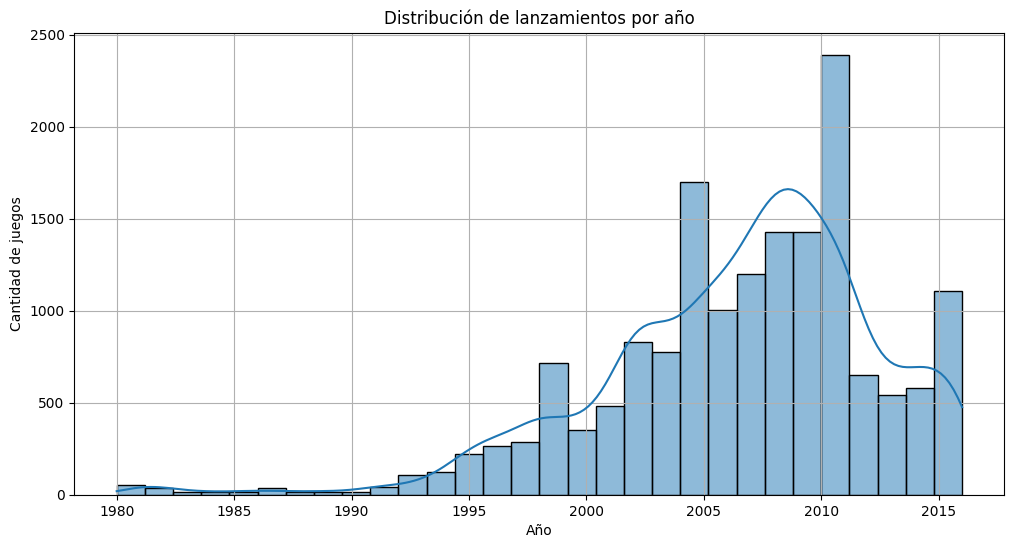

In [19]:
#3.1
#Distribución de juegos lanzados por diferentes años
games.groupby('year_of_release')['name'].count()

plt.figure(figsize=(12, 6))
sns.histplot(games['year_of_release'].dropna(), bins=30, kde=True)
plt.title('Distribución de lanzamientos por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de juegos')
plt.grid(True)
plt.show()

    - A partir de 1994 se duplico el lanzamiento de videojuegos un 100% y de ahí en adelante continuó creciendo. Respaldamos este creciemiento con los datos de lanzamientos de una de las consolas más exitosas de la historía el PlayStation (1994).

#### 3.2 - Observa cómo varían las ventas de una plataforma a otra. 

In [20]:
#3.2
#Varianza de ventas de una plataforma a otra
games.groupby('platform')[['na_sales','eu_sales', 'jp_sales', 'other_sales', 'total_sales']].sum().sort_values(by='total_sales', ascending=False)

,na_sales,eu_sales,jp_sales,other_sales,total_sales
platform,,,,,
PS2,583.84,339.29,139.20,193.44,1255.77
X360,602.47,270.76,12.43,85.76,971.42
PS3,393.49,330.29,80.19,135.68,939.65
Wii,496.90,262.21,69.33,79.07,907.51
DS,382.40,188.89,175.57,59.26,806.12
PS,336.52,213.61,139.82,40.91,730.86
GBA,187.54,75.25,47.33,7.73,317.85
PS4,108.74,141.09,15.96,48.35,314.14
PSP,109.17,66.68,76.78,41.42,294.05


#### 3.3 - Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. 

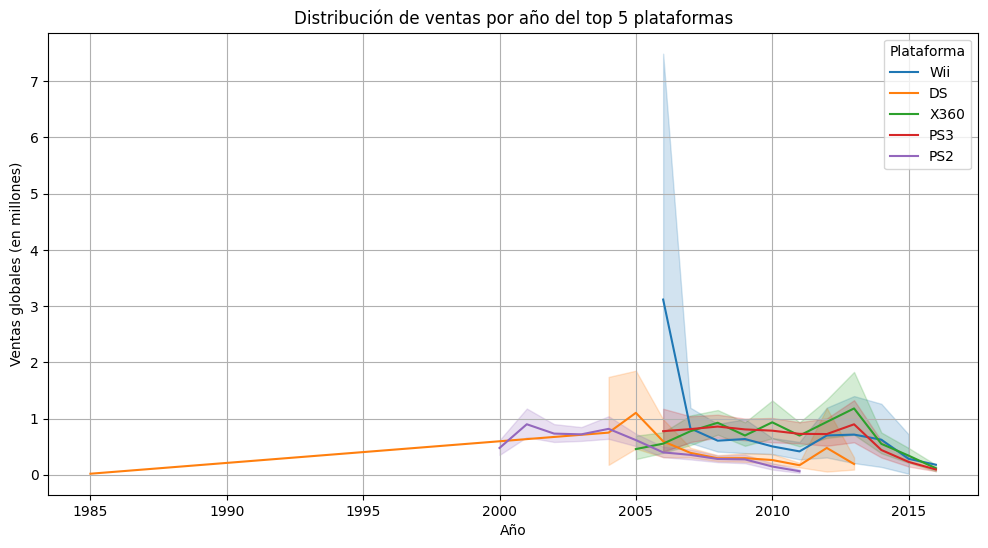

In [21]:
#3.3
#Distribución por de ventas por año del top 5 de plataformas
top_platforms_sales= games.groupby('platform')['total_sales'].sum().nlargest(5)
top_platforms_list = top_platforms_sales.index.tolist()
top_platforms= games[games['platform'].isin(top_platforms_list)]
    
plt.figure(figsize=(12, 6))
sns.lineplot(data=top_platforms, x='year_of_release', y='total_sales', hue='platform')
plt.title('Distribución de ventas por año del top 5 plataformas')
plt.xlabel('Año')
plt.ylabel('Ventas globales (en millones)')
plt.legend(title='Plataforma')
plt.grid(True)
plt.show()

#### 3.4 - Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [22]:
#3.4
#Identificar plataformas desaparecidas
discontinued_platforms = games.groupby('platform')['year_of_release'].agg(['min', 'max'])
max_year = games['year_of_release'].max()
discontinued_platforms = discontinued_platforms[discontinued_platforms['max'] < max_year - 1]

# Calcular tiempos promedio de aparición y desaparición
discontinued_platforms['duration'] = discontinued_platforms['max'] - discontinued_platforms['min']
average_lifespan = discontinued_platforms['duration'].mean()
discontinued_platforms
print('Tiempo promedio de vida de una consola:',average_lifespan)

Tiempo promedio de vida de una consola: 6.809523809523809


#### 3.5 - Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017. Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.

3.5

    - Al conocer que el promedio de vida de una consola es de practicamente 7 años (6.8) entonces para las proyecciones del 2017 se tomarán los datos de los ultimos 4 años. De esta forma sabremos si las consolas están creciendo, están en su pico o si ya están en declive para apostar especialmente por las primeras dos etapas.

In [23]:
# Filtrar por un nuevo DF los datos de los ultimos 4 años
games_recent = games[games['year_of_release'] >= games['year_of_release'].max() - 3]
games_recent.sample(5)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
14152,Pro Cycling Manager 2016,PC,2016,Sports,0.00,0.03,0.00,0.00,64.0,4.8,RP,0.03
1978,EA Sports UFC,PS4,2014,Sports,0.46,0.41,0.01,0.17,70.0,6.1,T,1.05
10405,Fate/Extella: The Umbral Star,PS4,2016,Action,0.00,0.00,0.11,0.00,NaN,NaN,T,0.11
8339,Deus Ex: Mankind Divided,XOne,2016,Role-Playing,0.09,0.06,0.00,0.01,83.0,7.2,M,0.16
6052,Dragon Ball Heroes: Ultimate Mission,3DS,2013,Misc,0.00,0.00,0.29,0.00,NaN,NaN,RP,0.29


#### 3.6 - ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

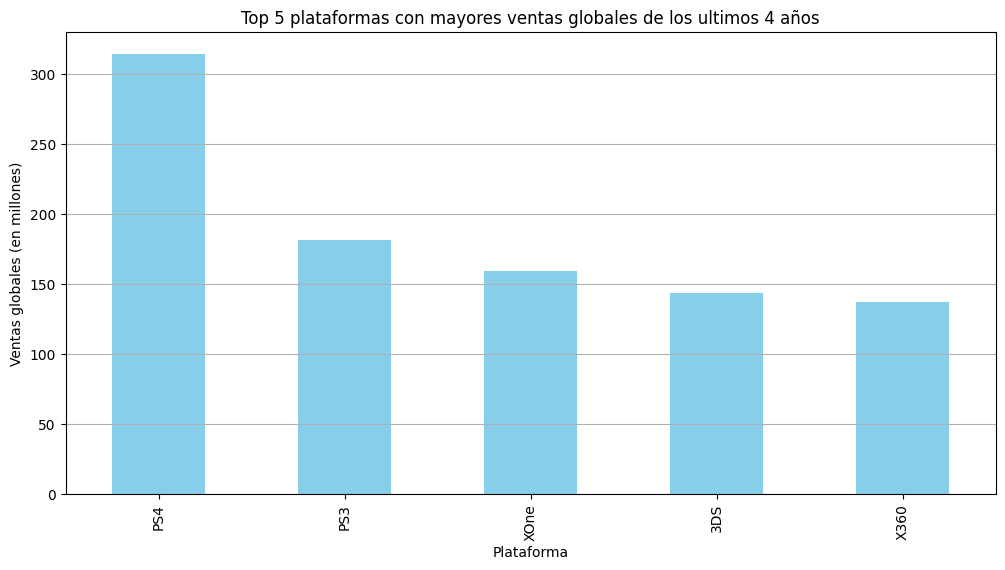

In [24]:
#3.6
#Nuevo top 5 de ventas totales por consola de los ultimos 4 años
top_platforms_sales= games_recent.groupby('platform')['total_sales'].sum().nlargest(5)

plt.figure(figsize=(12, 6))
top_platforms_sales.plot(kind='bar', color='skyblue')
plt.title('Top 5 plataformas con mayores ventas globales de los ultimos 4 años')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (en millones)')
plt.grid(axis='y')
plt.show()

In [25]:
# Identificación de consolas en crecimiento y decrecimiento
growth_trends = games_recent.groupby(['platform', 'year_of_release'])['total_sales'].sum().unstack().fillna(0)
growth_trends['trend'] = growth_trends.iloc[:, -1] - growth_trends.iloc[:, 0]
growth_trends= growth_trends[['trend']].sort_values(by='trend', ascending=False)
print(growth_trends)

#creamos una nueva lista de consolas (PC forzosamente incluido) que tienen 4 o menos años de vida
lifespan_platforms = games.groupby('platform')['year_of_release'].agg(['min', 'max'])
max_year = games['year_of_release'].max()
lifespan_platforms = lifespan_platforms[lifespan_platforms['max'] <= max_year]
lifespan_platforms['duration'] = lifespan_platforms['max'] - lifespan_platforms['min']
lifespan_platforms= lifespan_platforms[lifespan_platforms['max']>=max_year-3]
lifespan_platforms

year_of_release   trend
platform               
PS4               43.26
XOne               7.19
DS                -1.54
PSP               -3.14
PSV               -6.34
PC                -7.13
Wii               -8.41
WiiU             -17.05
3DS              -41.43
X360             -87.06
PS3             -109.65


,min,max,duration
platform,,,
3DS,2011,2016,5
DS,1985,2013,28
PC,1985,2016,31
PS3,2006,2016,10
PS4,2013,2016,3
PSP,2004,2015,11
PSV,2011,2016,5
Wii,2006,2016,10
WiiU,2012,2016,4


    - Ahora que conocemos la tendencia de ventas y el tiempo de promedio de vida de las consolas (7 años) podemos tomar los ultimos 4 años de ventas de videojuegos para tomar decisiones (2012 - 2016).
    - Las 5 consolas elegidas sobre las cuales nos enfocaremos serán las siguientes: 
    
    PS4 / 3 años de antigüedad / tendencia de 43.26%
    XONE / 3 años de antgüedad / tendencia de 7.19%
    PSV / 5 años de antigüedad / tendencia de -6.34%
    WiiU / 4 años de antigüedad / tendencia de -17.05
    3DS / 5 años de antiguedad / tendencia de -41.13%

    - Esta decision fue tomada principalmente por la antiguedad de las consolas, que el 2016 haya sido el año de su lanzamiento mas reciente de juegos y tendencia positiva o ligeramente negativa. En cuanto a la edad PC es una consola engañosa pero que debido a su concepto practicamente cada año se renueva su fecha de lanzamiento debido a que año con año se continuan construyendo dispositivos más potentes.


#### 3.7 - Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

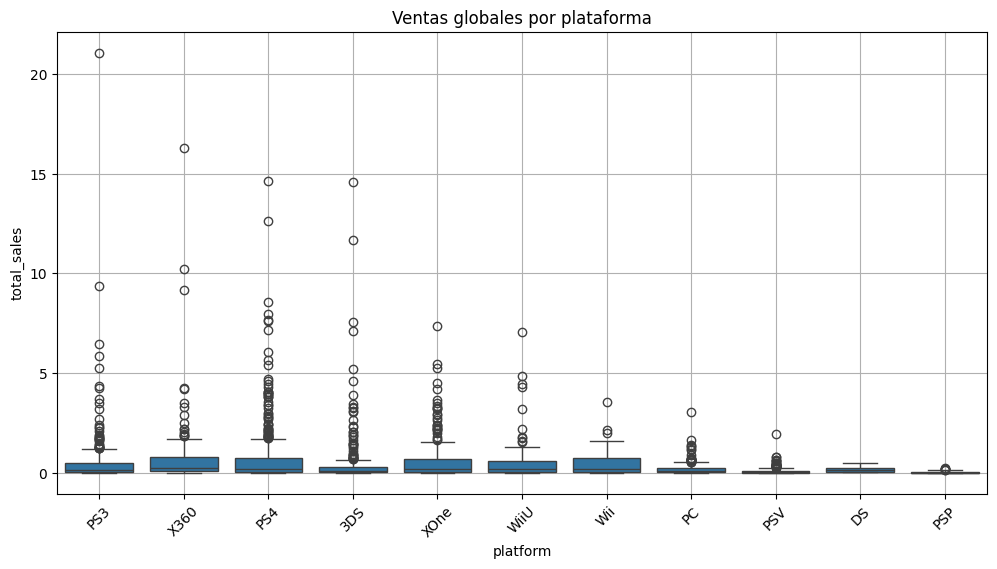

In [26]:
#3.7
#Diagrama de caja de ventas globales por plataforma
plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='total_sales', data=games_recent)
plt.title('Ventas globales por plataforma')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

    - Es curioso el comportamiento de como algunas consolas (X360, PS4, Xone, WiiU, Wii) predominan en su generalidad en ventas totales, sin embargo cuentan con picos muy distintos entre sus juegos top que marcan la díferencia en el éxito actual de dicha consola.
    - También es remarcable la plataforma de PS3 que ya se encuentra practicamente en su fase final de vida y que se ve reflejado en el al ser el sexto lugar en el promedio de sus ventas pero con un juego que liderea con facilidad al resto.
    - De igual forma encontramos plataformas que ya se encuentran en un fuerte declive estos años pero que en el acumulado total fueron éxitos de ventas como el DS y el PSP.

#### 3.8 - Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

/tmp/ipykernel_13329/3571126504.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_recent['critic_new_score']= games_recent['critic_score']/10


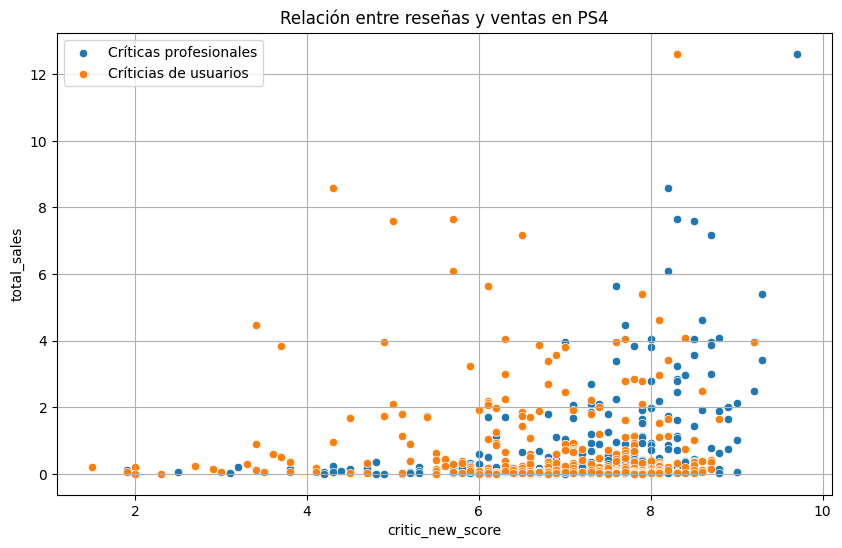

Correlación entre críticas profesionales y ventas en PS4: 0.41
Correlación entre reseñas de usuarios y ventas en PS4: -0.03


In [27]:
#3.8
# Se encontro que los usuarios califican con números del 0 al 10 mientras que la crítica profesional da calificaciones del 0 al 100
#por lo que será necesario convertir los scores de la critica a base 10 
games_recent['critic_new_score']= games_recent['critic_score']/10 

#Gráfico de dispersión y correlación para reseñas vs ventas en la plataforma de ventas más alta PS4
popular_platform = top_platforms_sales.index[0]
popular_data = games_recent[games_recent['platform'] == popular_platform]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='critic_new_score', y='total_sales', data=popular_data, label='Críticas profesionales')
sns.scatterplot(x='user_score', y='total_sales', data=popular_data, label='Críticias de usuarios')
plt.title(f'Relación entre reseñas y ventas en {popular_platform}')
plt.legend()
plt.grid(True)
plt.show()

# Correlación
correlation_critic = popular_data[['critic_new_score', 'total_sales']].corr().iloc[0, 1]
correlation_user = popular_data[['user_score', 'total_sales']].corr().iloc[0, 1]
print(f"Correlación entre críticas profesionales y ventas en {popular_platform}: {correlation_critic:.2f}")
print(f"Correlación entre reseñas de usuarios y ventas en {popular_platform}: {correlation_user:.2f}")

#### 3.9 - Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

3.9

    - Como se puede observar en la gráfica de dispersión elegimos la consola PS4 al ser la de mayor cantidad de ventas y esperando que tuviese niveles altos tanto en las reseñas de la crítica como de los usuarios. Para mi sorpresa ambas críticas se encontraban en escalas distintas, mientras que la critica calificaba del 0 al 100 los usuarios eran del 0 al 10 por lo que para no perder exactitud con los scores divideremos entre 10 las críticas de los expertos creando una nueva serie llamada USER_NEW_SCORE
    - Ahora, analizando la gráfica de distribución tiene mucho sentido que la plataforma PS4 sea la lider en ventas y en crecimiento ya que el promedio supera con facilidad la calificación de 6. Con esto confirmamos que la plataforma elegida es ideal como modelo exitoso para distintas pruebas.
    - Una vez calculadas las correlaciones entre profesionales y usuarios encontramos que la primera tiene tendencía positiva y la segunda ligeramente negativa. Esto indica que que a mayor nivel en las criticas de expertos existe una correlación moderadamente positiva con altos niveles de ventas; mientras que una correlación ligeramente negativa para las reseñas de usuarios contra las ventas.

#### 3.10 - Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [28]:
#3.10
#Distribución de juegos por género
genre_sales = games_recent.groupby('genre')[['eu_sales','jp_sales','na_sales','other_sales','total_sales']].sum().sort_values(by='total_sales', ascending=False)
genre_sales['game_count']= games_recent['genre'].value_counts()
print("Géneros más rentables:")
print(genre_sales)

Géneros más rentables:
              eu_sales  jp_sales  na_sales  other_sales  total_sales  \
genre                                                                  
Action          118.13     40.49    126.05        37.20       321.87   
Shooter          87.86      6.61    109.74        28.77       232.98   
Sports           60.52      5.41     65.27        19.45       150.65   
Role-Playing     36.97     51.04     46.40        11.48       145.89   
Misc             20.04      9.20     27.49         6.09        62.82   
Platform         15.58      4.79     18.14         4.12        42.63   
Racing           20.19      2.30     12.96         4.44        39.89   
Fighting          8.55      7.65     15.55         3.56        35.31   
Adventure         8.25      5.82      7.14         2.43        23.64   
Simulation       10.92      4.52      4.86         1.46        21.76   
Strategy          4.22      1.77      3.28         0.81        10.08   
Puzzle            1.00      1.18      0.8

    - Al observar la tabla de ventas por género encontramos que el top 3 de total de ventas son: Action, Shooter y Sports. Siendo predominante Action en 3 de las 4 regiones ya que en Japón es el segundo género más vendido justo atras de Role-Playing. Esto sabiendo que Japón es uno de los mayores productores de juegos de esta categoría.
    - Para los otros 2 géneros siguientes las ventas totales corresponden a su posición.
    - Por otro lado los 3 menos vendidos que son: Simulation, Strategy y Puzzle. Para el ultimo y penultimo lugar sus lugares son respaldados por sus bajas ventas, sin embargo para Simulation apreciamos que para la región de la unión europea es el quinto lugar de abajo para arriba; y en la región japonesa es el cuarto menos vendido.

# Paso 4. Crea un perfil de usuario para cada región

Para cada región (NA, UE, JP) determina:

#### 4.1 - Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.
#### 4.2 - Los cinco géneros principales. Explica la diferencia.
#### 4.3 - Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [29]:
#Perfil de usuario por región
regions = ['na_sales', 'eu_sales', 'jp_sales']
profile_data = []

#Método que recorre todas las regiones de la lista REGIONS y almacena los datos en PROFILE DATA
for region in regions:
    #4.1 - Top 5 plataformas
    top_platforms_region = games_recent.groupby('platform')[region].sum().nlargest(5)
    
    #4.2 - Top 5 géneros
    top_genres_region = games_recent.groupby('genre')[region].sum().nlargest(5)
    
    #4.3 - Impacto del rating ESRB
    rating_impact = games_recent.groupby('rating')[region].sum().nlargest(5)
    
    profile_data.append([region, top_platforms_region.index.tolist(), top_genres_region.index.tolist(), rating_impact.index.tolist()])

# Crear un DataFrame con el perfil de usuario por región
profile_df = pd.DataFrame(profile_data, columns=['Región', 'Top 5 Plataformas', 'Top 5 Géneros', 'Rating más común'])
print("\nPerfil de usuario por región:")
print(profile_df)
print("\n",games_recent['rating'].value_counts())


Perfil de usuario por región:
     Región            Top 5 Plataformas  \
0  na_sales  [PS4, XOne, X360, PS3, 3DS]   
1  eu_sales  [PS4, PS3, XOne, X360, 3DS]   
2  jp_sales   [3DS, PS3, PSV, PS4, WiiU]   

                                     Top 5 Géneros     Rating más común  
0    [Action, Shooter, Sports, Role-Playing, Misc]  [M, RP, E, E10+, T]  
1  [Action, Shooter, Sports, Role-Playing, Racing]  [M, E, RP, E10+, T]  
2  [Role-Playing, Action, Misc, Fighting, Shooter]  [RP, T, E, M, E10+]  

 rating
RP      977
M       369
T       333
E       302
E10+    252
Name: count, dtype: int64


    - Dando un rápido vistazo a los perfiles de cada región encontramos que nuestra apuesta por las consolas con más futuro fue bastante precisa siendo que la lista era: PS4, XONE, PSV, WIIU y 3DS. Estas consolas las encontramos en practicamente como top en todas las regiones.
    - Tal como observamos en esta tabla así como en la anterior los 5 generos más jugados son practicamente iguales. Se presentaron las diferencias únicas diferencias en los géneros de MISC en NA y JP; SPORTS en NA y EU; y RACING solo en EU. Ahora que si calculamos la cantidad de juegos por genero notamos que la cantidad lanzadas con estos generos corresponden en mismo orden de mayor a menor con la lista de top 5 de géneros.
    - Por ultimo en los ratings encontramos un comportamiento curioso en el que yo suponía dependerían las altas ventas de un rating con la cantidad de juegos con dicho clasificamiento, sin embargo está por obviedad mayormente relacionada a los géneros más vendidos de ACTION Y SHOOTER que normalmente cuentan con un rating de M.

# Paso 5. Prueba las siguientes hipótesis:

#### 5.1 — Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [30]:
#Hipótesis 1
#H0 - Calificaciones promedio de los usuarios para la plataforma de XONE y PC son DISTINTAS
#H1 - Calificaciones promedio de los usuarios para la plataforma de XONE y PC son IGUALES

#Filtramos el DF solo por los scores de usuarios de XOne y PC
scores_xone= games[games['platform']=='XOne']['user_score'].dropna()
scores_pc= games[games['platform']=='PC']['user_score'].dropna()

#Calculamos las varianzas para saber si las muestras son estadisticamente similares
print('Varianza Xone:', scores_xone.var())
print('Varianza PC:', scores_pc.var())

#valor alpha
alpha = 0.05

#Prueba t student
#Como encontramos una varianza con una diferencia menor a 4, entonces agregaremos equal_var=True
platform_hipotesis = st.ttest_ind(scores_xone, scores_pc, equal_var=True)

#Extraer valor P
print('Valor p: ', platform_hipotesis.pvalue)

#Comparar valor P con el umbral
if platform_hipotesis.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Varianza Xone: 1.9069968429360695
Varianza PC: 2.3407871413372066
Valor p:  1.3896435533548819e-05
Rechazamos la hipótesis nula


#### 5.2 — Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [31]:
#Hipotesis 2
#H0 - Calificaciones promedio de los usuarios para los géneros de ACTION y SPORTS son IGUALES
#H1 - Calificaciones promedio de los usuarios para los géneros de ACTION y SPORTS son DISTINTAS

#Filtramos el DF solo por los scores de usuarios de géneros de ACTION y SPORTS
scores_action= games[games['genre']=='Action']['user_score'].dropna()
scores_sports= games[games['genre']=='Sports']['user_score'].dropna()

#Calculamos las varianzas para saber si las muestras son estadisticamente similares
print('Varianza ACTION:', scores_action.var())
print('Varianza SPORTS:', scores_sports.var())

#Prueba t student

#Como encontramos una varianza con una diferencia menor a 4, entonces agregaremos equal_var=True
genres_hipotesis = st.ttest_ind(scores_action, scores_sports, equal_var=True)

#Extraer valor P
print('Valor p: ', genres_hipotesis.pvalue)

#Comparar valor P con el umbral
if genres_hipotesis.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Varianza ACTION: 2.031746898033205
Varianza SPORTS: 2.5965147189730033
Valor p:  0.10406951359049141
No podemos rechazar la hipótesis nula


#### 5.3 — Cómo formulaste las hipótesis nula y alternativa.

    - Desde el cálculo de la varianza para ambas hipótesis hemos detectado las similitudes entre las muestras en cada caso, por lo que es necesario activar EQUAL_VAR=True en la función del calculo de ttest.
    - Analizando la sentencia de la Hipótesis 1 encontramos que H0 y H1 se encuentran hasta cierto punto invertidas ya que normalmente es H0 la que demuestra la Igualdad y H1 la Diferencia. El valor P es mucho menor que alpha por lo que Rechazamos la H0, esto significa que efectivamente H1 es cierta y existe una Igualdad en las calificaciones de los promedios de los scores de los usuarios para las plataformas de Xbox One y PC.
    - Mientras que la segunda hipótesis está estructurada de forma tradicional en la que H0 es Igualdad y H1 Diferencia en los promedios de las muestras de los géneros ACTION y SPORT. El valor P para esta segunda prueba es de 0.14, esto indica que NO podemos rechazar la hipótesis nula y podemos concluir que los promedios son estadisiticamente similares.

#### 5.4 — Qué criterio utilizaste para probar las hipótesis y por qué.

    - Para ambos casos se necesita comparar la igualdad/diferencia entre la media de dos muestras por lo que se utilizará la prueba T Student, con la función de EQUAL_VAR=True por tener una varianza entre las muesras con una diferencia menor a 4 y se eligió una valor de alpha de 0.05 para tener una certeza cercana al 95%.

# Paso 6. Escribe una conclusión general

Al analizar los datos de origen encontramos que faltan mucha información entre estos registros debido principalmente a las exclusividades de lanzamientos solo en ciertas regiones, así como que que contamos con información desde los años 80's y que por lo misma muchas de las entidades que se encargaban de dar una critica experta o una clasificación de edad no existían o se encontraban en una etapa muy temprana; también por que anteriormente en ciertos juegos la variedad de plataformas para los que eran lanzados era muy amplia y se generaban practicamente juegos distintos que generaban experiencias distintas y por lo tanto scores, géneros o clasificaciones dispares. Continuando con la limpieza y modificación de datos se realizarón cambios de tipo solo en las series de YEAR_OF_REALESE, CRITIC_SCORE y USER_SCORE; se mantuvieron practicamente en su totalidad los datos nulos excepto en GENRE y se sustituyó el string TBD por nulos para la serie USER_SCORE ya que estas siglas indicaban que aún no se tenía una calificación a los juegos por parte de los usuarios.

Una vez que calculamos la tiempo de vida de una consola que es de 7 años se tomaron en consideración de los datos de 4 años atrás para tomar decisiones sobre las consolas sobre las cuales se apostaría el enfoque de venta, esta lista fue confirmada despues al analizar el desempeño de ventas de consolas por géneros, clasificación y regiones que nos brindan además la información sobre los tipos de juegos por los que podemos apostar para buscar conseguir las mejores ventas. La lista de Plataformas, Géneros y Clasificaciones es expuesta a continuación:
        - PS4, XONE, PSV, WiiU, 3DS 
        - Action, Shooter, Sports, Role-Playing, Misc
        - M, RP, E, E10+, T

De igual manera escogimos a la PS4 para determinar la correlación entre las ventas de sus juegos y las calificaciones de usuarios o críticos especializados, encontrando una correlación positiva en las altas ventas en juegos con buenas califiaciones de la crítica y una ligeremente negativa contra las calificaiones de usuarios.

Por ultimo buscamos experimentar con dos hipótesis, la primera para buscar la igualdad de las medias entre las calificaciones de usuarios para las plataformas de Xbox One contra PC encontrando que "Rechazamos la hipótesis nula" ya que ambas medias son matematicamente similares. Para la segunda hipótesis comparamos nuevamente las clasificaciones de usuarios esta vez entre el género de Acción contra Deportivos, resultando que "No podemos rechazar la hipótesis nula" confirmando igualmente que ambas medias son similares.